# Gradient Descent: fixed learning rate and Armijo line search

We will implement **gradient descent** in two steps:

1. **Fixed learning rate** (constant step size)
2. **Armijo backtracking line search** (automatic step size selection)

Then you will repeat the same ideas for the **Rosenbrock function** (a classic non-convex test problem).

---

## Reminder: Gradient descent

To minimize a differentiable function \(f\), gradient descent updates

$
x_{k+1} = x_k - \alpha_k \nabla f(x_k),
$

where $\alpha_k > 0$ is the learning rate / step size.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Part A — 1D warm-up (easy)

We minimize

$
f(x) = (x-3)^2 + 1,
\qquad f'(x) = 2(x-3).
$

The minimizer is $x^* = 3$.

---

💻 <font color='blue'>**Task A1:** Define `f(x)` and its derivative `df(x)`.</font>


In [ ]:
# function and derivative (fill in)
def f(x):
    return (x-3)**2+1

def df(x):
    return 2*(x-3)

💻 <font color='blue'>**Task A2:** Implement gradient descent with a **fixed** learning rate.</font>

Use:
- initial value `x0 = -4`
- `n_iter = 30`
- store all iterates in a list `xs`

Update:
$
x \leftarrow x - \alpha f'(x).
$


In [ ]:
alpha = 0.3   # try e.g. 0.1, 0.2, 0.8, 1.1 ...
x0 = -4.0
n_iter = 30

xs = [x0]
x = x0
for k in range(n_iter):
    x = x-alpha*df(x)
    xs.append(x)

print("final x =", xs[-1], "  f(x) =", f(xs[-1]))

💻 <font color='blue'>**Task A3:** Plot the function and the iterates.</font>

- Plot $f(x)$ on an interval, e.g. $[-5, 6]$
- Overlay the iterate points $(x_k, f(x_k))$


In [ ]:
x_plot = np.linspace(-5, 6, 400)

plt.figure()
plt.plot(x_plot, f(x_plot), label="f(x)")
plt.scatter(xs ,f(np.array(xs)), label="iterates")
plt.grid(True)
plt.legend()
plt.show()

💻 <font color='blue'>**Task A4:** Play with the learning rate `alpha`.</font>

Try values like:
- `0.01` (very small)
- `0.1` (reasonable)
- `0.8` (fast-ish)
- `1.1` (what happens?)

Write down what you observe:
- convergence speed
- oscillations
- divergence


# Part B — Armijo backtracking line search (1D)

Instead of fixing $\alpha$, Armijo selects it automatically. 
More details can be found here: https://www.math.ntnu.no/emner/TMA4180/2024v/Backtracking.pdf

**Armijo condition** (1D):

Let $g = f'(x)$. We accept $\alpha$ if

$
f(x - \alpha g) \le f(x) - c \alpha g^2,
$

with parameters $0 < c < 1$ and $0 < \rho < 1$.

**Backtracking:**
1. start with $\alpha = 1$
2. while condition is not satisfied, set $\alpha \leftarrow \rho \alpha$

---

💻 <font color='blue'>**Task B1:** Implement `armijo_step_1d(x)`.</font>


In [ ]:
def armijo_step_1d(x, c=1e-4, rho=0.5):
    alpha = 1.0
    g = df(x)

    # backtracking
    while f(x-alpha*g)>f(x)-c*alpha*(g**2):   # Armijo condition NOT satisfied
        alpha = rho*alpha

    return alpha

print(alpha)

💻 <font color='blue'>**Task B2:** Use Armijo in gradient descent.</font>

Compute iterates `xs_armijo` and compare to the fixed-learning-rate version.


In [ ]:
x = x0
xs_armijo = [x]

for k in range(n_iter):
    alpha = armijo_step_1d(x)
    x = x -alpha*df(x)
    xs_armijo.append(x)

print("final x =", xs_armijo[-1], "  f(x) =", f(xs_armijo[-1]))

In [ ]:
plt.figure()
plt.plot(x_plot, f(x_plot), label="f(x)")
plt.scatter(xs, f(np.array(xs)), label="fixed step")
plt.scatter(xs_armijo, f(np.array(xs_armijo)), label="Armijo")
plt.grid(True)
plt.legend()
plt.show()

# Part C — Rosenbrock function (additional exercise)

Now we switch to a 2D test problem.

$
f(x,y) = (1-x)^2 + 100(y-x^2)^2.
$

This function has a global minimum at $(x^*,y^*)=(1,1)$, but it is **hard** for gradient descent because it has a narrow curved valley.

---

💻 <font color='blue'>**Task C1:** Implement `rosenbrock(z)` and its gradient `grad_rosenbrock(z)`.</font>

Represent the point as a NumPy array `z = np.array([x, y])`.


In [ ]:
def rosenbrock(z):
    x, y = z[0], z[1]
    return (1-x)**2+100*(y-x**2)**2
def grad_rosenbrock(z):
    x, y = z[0], z[1]
    # fill in the gradient as a 2D vector np.array([df/dx, df/dy])
    return np.array([2*(x-1)-400*x*(y-x**2) , 200*(y-x**2)])

Let's plot this 2D function:

In [ ]:
x_plot = np.linspace(-5, 5, 100)
y_plot = np.linspace(-5, 5, 100)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

# 3. Stack into a single array for the function
Z_plot = rosenbrock(np.array([X_plot, Y_plot]))

# 4. Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_plot, Y_plot, Z_plot, cmap='viridis')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Surface Plot of f(x, y) = x² + y²')

fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

💻 <font color='blue'>**Task C2:** Write a fixed-step gradient descent function for 2D.</font>

- start at `z0 = np.array([-1.2, 1.0])`
- run e.g. `n_iter = 2000`
- try different learning rates `alpha` (you will likely need small values!)

Store the iterates in a list `zs`.


In [109]:
def gd_fixed(z0, alpha, n_iter,tol):
    z = z0.copy()
    zs = [z.copy()]
    for k in range(n_iter):
        z_new = z-alpha*grad_rosenbrock(z)
    
        if np.linalg.norm(z_new-z,2)<tol:
            break

        z=z_new
        
        zs.append(z_new.copy())
    return np.array(zs)

z0 = np.array([-1.2, 1.0])
alpha = 10**(-4)  # try 1e-3, 5e-4, 1e-4, ...
n_iter = 2000

zs = gd_fixed(z0, alpha, n_iter,10**(-100))
print("final z =", zs[-1], "  f(z) =", rosenbrock(zs[-1]))

final z = [-0.86337282  0.75349314]   f(z) = 3.4786877336088433


💻 <font color='blue'>**Task C3:** Plot the trajectory on a contour plot.</font>

This helps you *see* how the iterates move through the Rosenbrock valley.


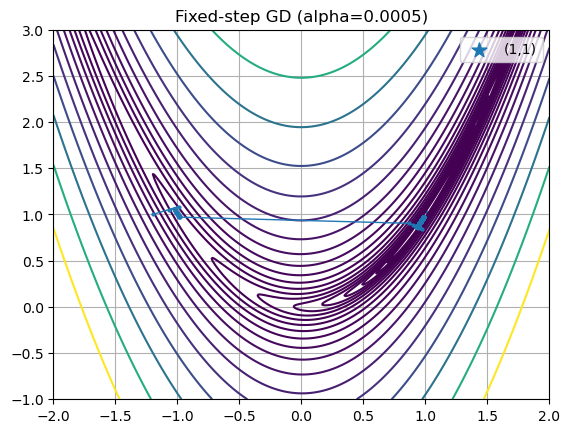

In [102]:
def plot_rosenbrock_contours_and_path(zs, title=""):
    # contour grid
    x = np.linspace(-2, 2, 400)
    y = np.linspace(-1, 3, 400)
    X, Y = np.meshgrid(x, y)
    Z = (1 - X)**2 + 100*(Y - X**2)**2

    plt.figure()
    levels = np.logspace(-1, 3, 20)
    plt.contour(X, Y, Z, levels=levels)
    plt.plot(zs[:,0], zs[:,1], marker="o", markersize=2, linewidth=1)
    plt.scatter([1.0], [1.0], marker="*", s=120, label="(1,1)")
    plt.grid(True)
    plt.title(title)
    plt.legend()
    plt.show()

plot_rosenbrock_contours_and_path(zs, title=f"Fixed-step GD (alpha={alpha})")

## Part D — Armijo line search for Rosenbrock

Now implement Armijo for the 2D case.

Armijo condition:

Let $g = \nabla f(z)$. Accept $\alpha$ if

$
f(z - \alpha g) \le f(z) - c \alpha \|g\|^2.
$

---

💻 <font color='blue'>**Task D1:** Implement `armijo_step(z, f, grad_f)` (generic, works in any dimension).</font>


In [103]:
def armijo_step(z, f, grad_f, c=1e-4, rho=0.5):
    alpha = 1.0
    g = grad_f(z)

    while f(z-alpha*g)>f(z)-c*alpha*(np.linalg.norm(g)**2):   # Armijo condition NOT satisfied
        alpha = rho*alpha

    return alpha

💻 <font color='blue'>**Task D2:** Implement gradient descent with Armijo for Rosenbrock.</font>

Compare:
- convergence speed (objective values)
- the path shape in the contour plot


In [104]:
def gd_armijo(z0, n_iter, tol =10**(-6)):
    z = z0.copy()
    zs = [z.copy()]
    for k in range(n_iter):
        alpha = armijo_step(z, rosenbrock, grad_rosenbrock)
        z_new = z-alpha*grad_rosenbrock(z)

        if np.linalg.norm(z_new-z,2)<tol:
            break

        z=z_new
        
        zs.append(z.copy())
    return np.array(zs)

zs_a = gd_armijo(z0, n_iter=2000)
print("final z =", zs_a[-1], "  f(z) =", rosenbrock(zs_a[-1]))

final z = [0.98865264 0.97736244]   f(z) = 0.00012927530765324282


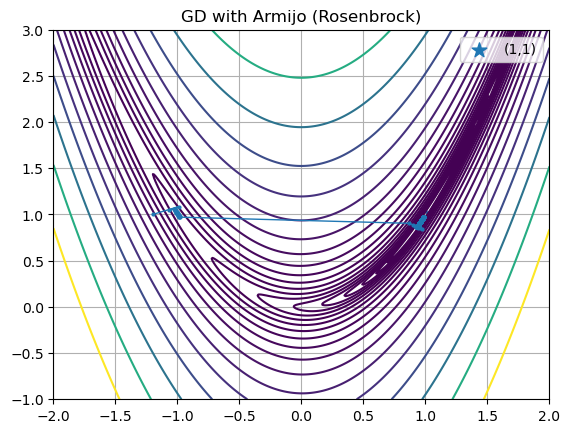

In [105]:
plot_rosenbrock_contours_and_path(zs_a, title="GD with Armijo (Rosenbrock)")

💻 <font color='blue'>**Task D3 (optional):** Compare objective values over iterations.</font>

Plot $f(z_k)$ for both methods (fixed step vs Armijo).


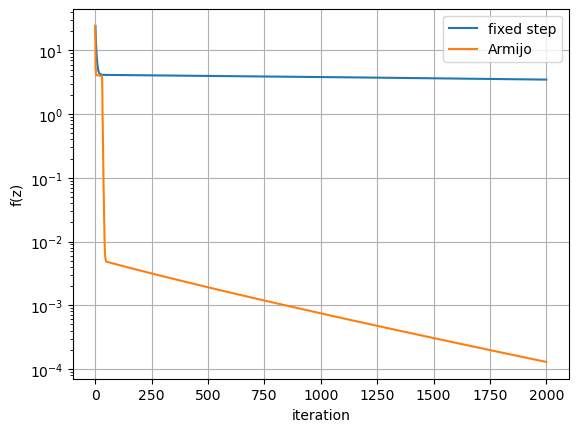

In [110]:
fs_fixed = np.array([rosenbrock(z) for z in zs])
fs_armijo = np.array([rosenbrock(z) for z in zs_a])

plt.figure()
plt.semilogy(fs_fixed, label="fixed step")
plt.semilogy(fs_armijo, label="Armijo")
plt.grid(True)
plt.legend()
plt.xlabel("iteration")
plt.ylabel("f(z)")
plt.show()

# What to hand in :-)

1. Your completed code (all `_+++_` filled in).
2. A short note on:
   - which fixed learning rates worked well in 1D and why
   - what went wrong for too large `alpha`
   - how Armijo adapts the step size
3. For Rosenbrock:
   - one fixed-step run that struggles
   - one fixed-step run that works (even if slow)
   - the Armijo run and your observations
